In [1]:
!pip install numpy matplotlib

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("images_xor", exist_ok=True)

In [3]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 0])

X_bias = np.c_[np.ones(len(X)), X]

print("Input:")
print(X)

print("\nOutput:")
print(y)

Input:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

Output:
[0 1 1 0]


In [4]:
weights = np.zeros(3)

learning_rate = 0.1
epochs = 10

update_count = 0

In [5]:
def activation(value):
    return 1 if value >= 0 else 0

In [6]:
def plot_boundary(weights, update):

    plt.figure(figsize=(6,6))

    for i, point in enumerate(X):
        color = "red" if y[i] == 1 else "blue"

        plt.scatter(
            point[0],
            point[1],
            c=color,
            s=150
        )

        plt.text(
            point[0]+0.03,
            point[1]+0.03,
            str(y[i])
        )

    x_values = np.linspace(-0.5, 1.5, 100)

    if weights[2] != 0:

        y_values = (
            -(weights[1]*x_values + weights[0])
            /
            weights[2]
        )

        plt.plot(
            x_values,
            y_values,
            color="black",
            label="Decision Boundary"
        )

    plt.xlim(-0.5,1.5)
    plt.ylim(-0.5,1.5)

    plt.xlabel("X1")
    plt.ylabel("X2")

    plt.title(
        f"Update {update}\nWeights={weights.round(2)}"
    )

    plt.grid()
    plt.legend()

    filename = f"images_xor/update_{update}.png"

    plt.savefig(
        filename,
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


Epoch: 1
Update 1: [-0.1  0.   0. ]


/tmp/ipykernel_1098/1801390950.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


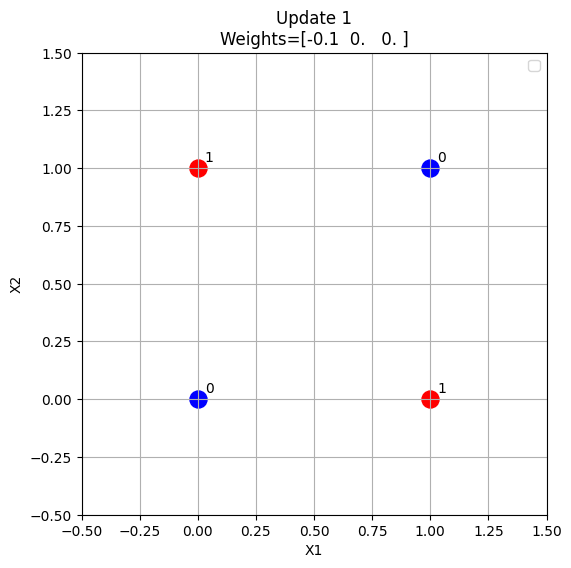

Update 2: [0.  0.  0.1]


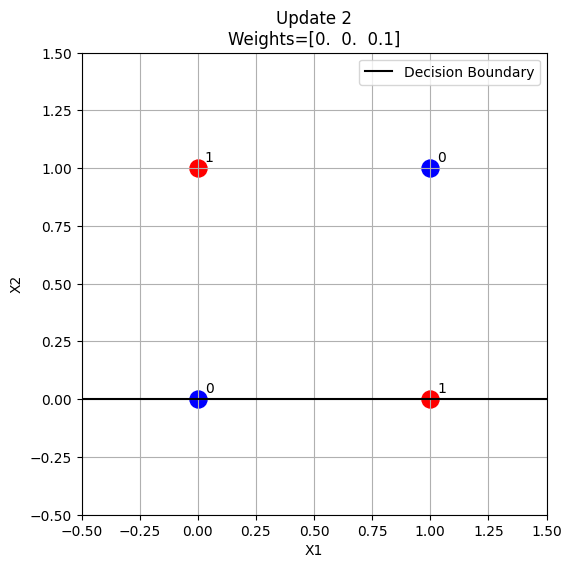

Update 3: [-0.1 -0.1  0. ]


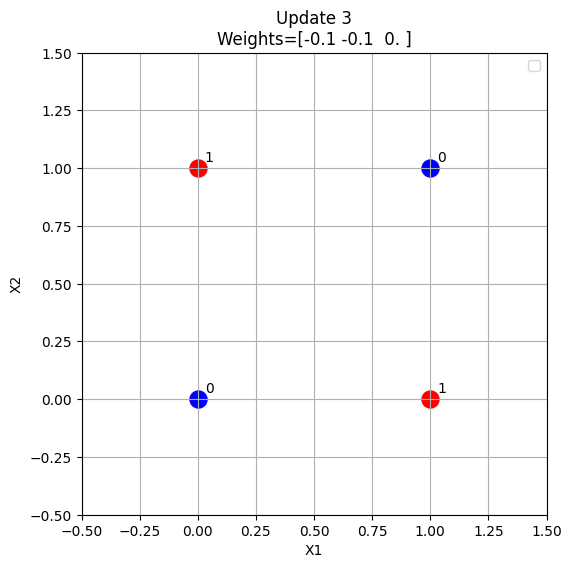


Epoch: 2
Update 4: [ 0.  -0.1  0.1]


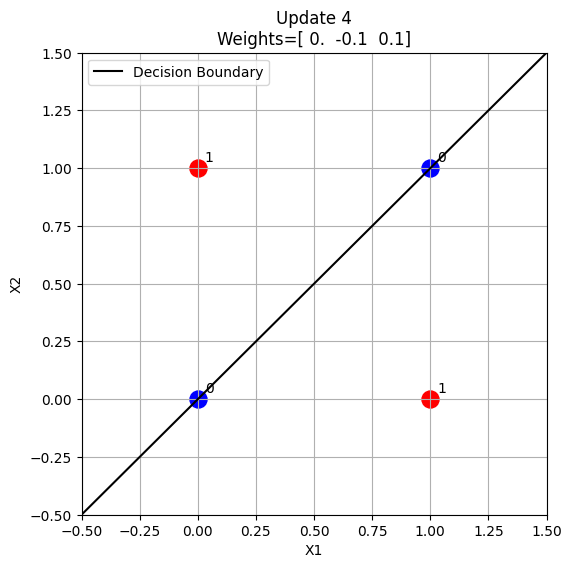

Update 5: [0.1 0.  0.1]


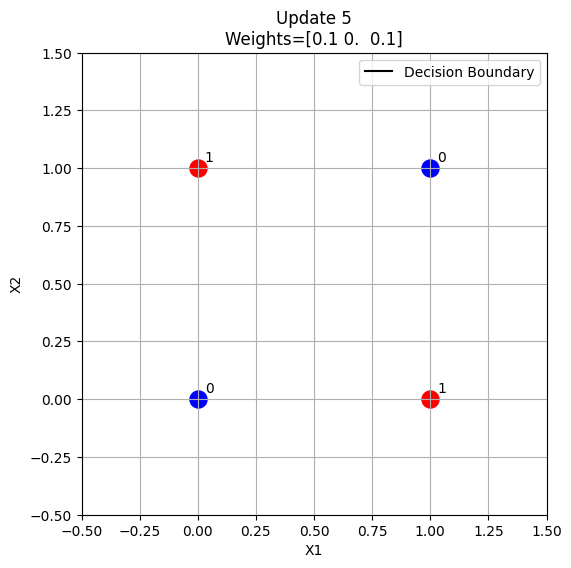

Update 6: [ 0.  -0.1  0. ]


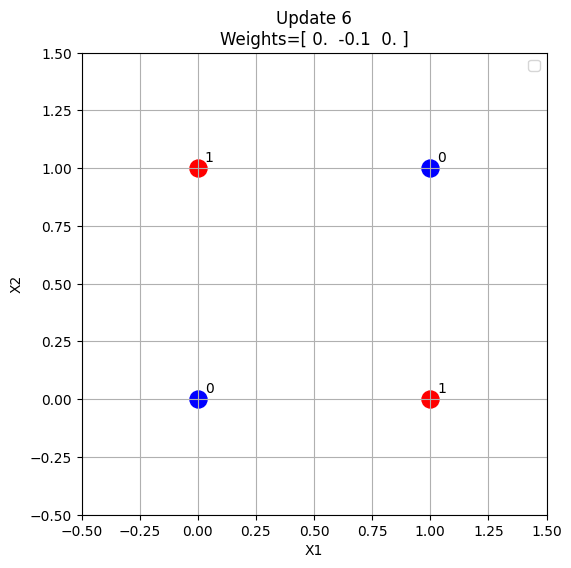


Epoch: 3
Update 7: [-0.1 -0.1  0. ]


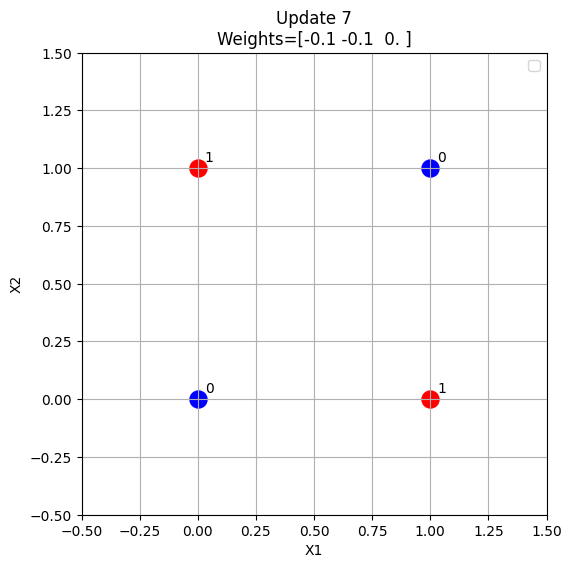

Update 8: [ 0.  -0.1  0.1]


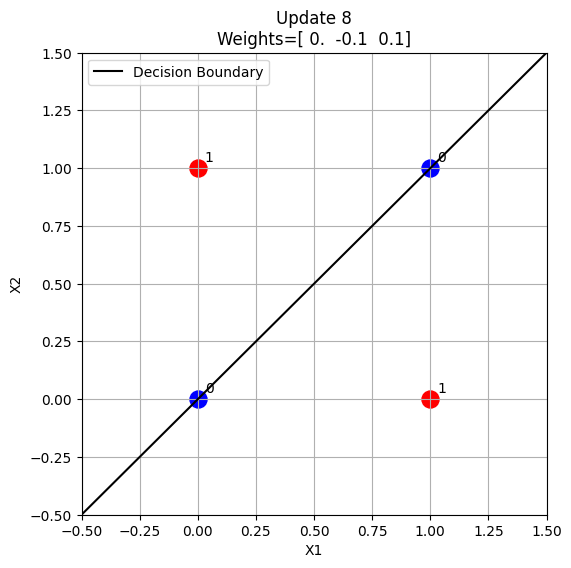

Update 9: [0.1 0.  0.1]


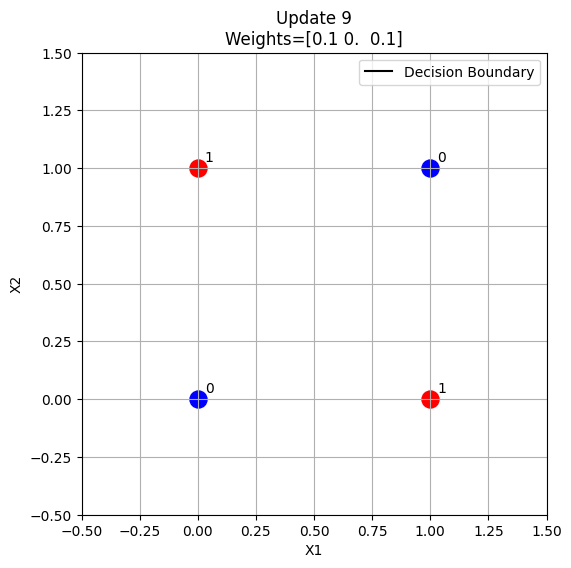

Update 10: [ 0.  -0.1  0. ]


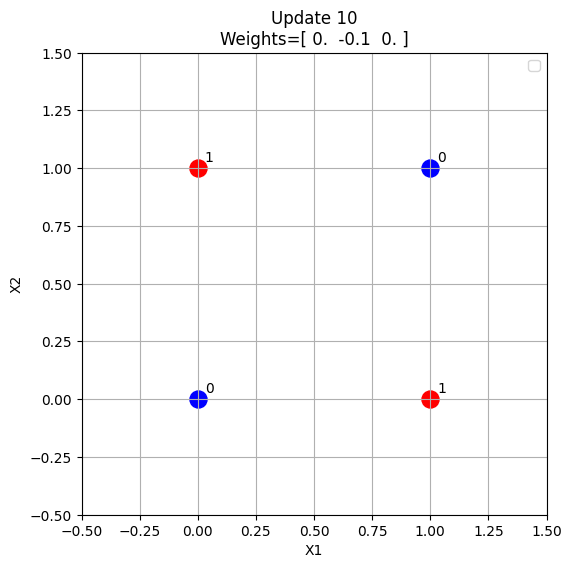


Epoch: 4
Update 11: [-0.1 -0.1  0. ]


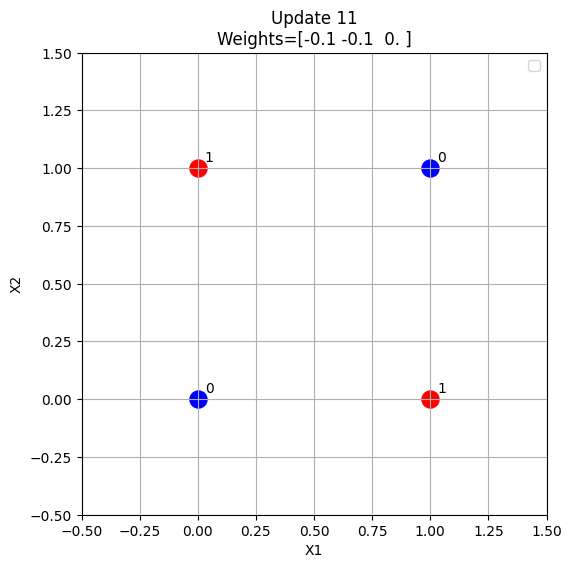

Update 12: [ 0.  -0.1  0.1]


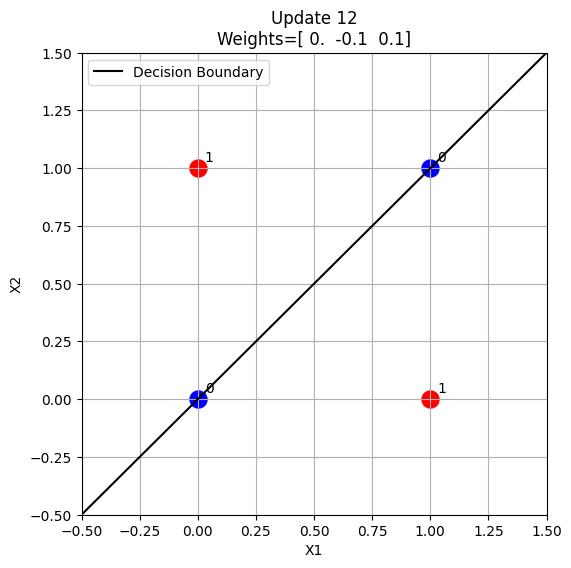

Update 13: [0.1 0.  0.1]


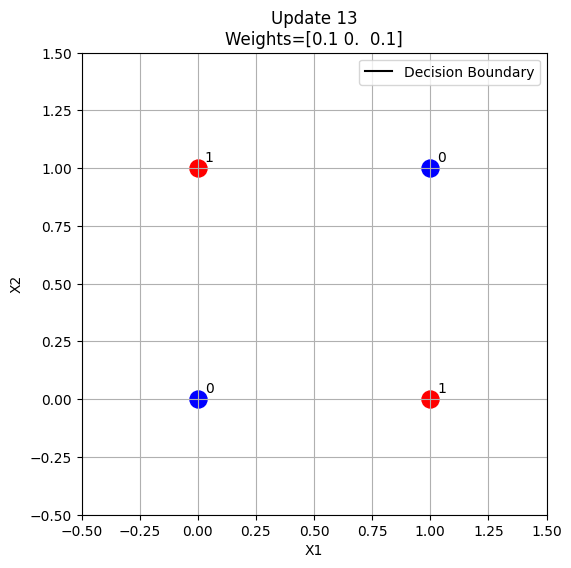

Update 14: [ 0.  -0.1  0. ]


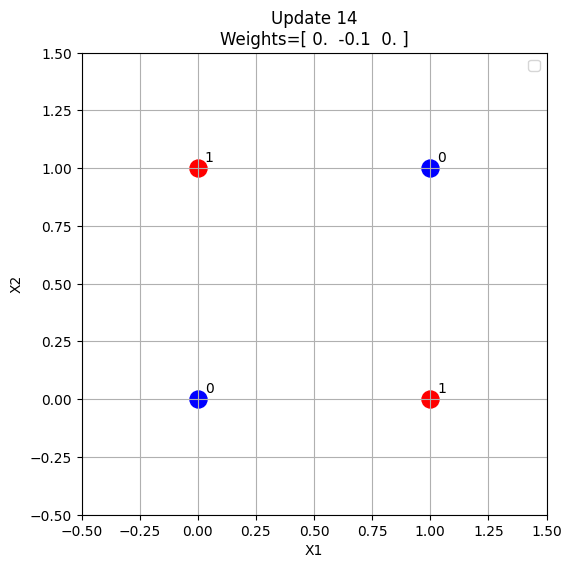


Epoch: 5
Update 15: [-0.1 -0.1  0. ]


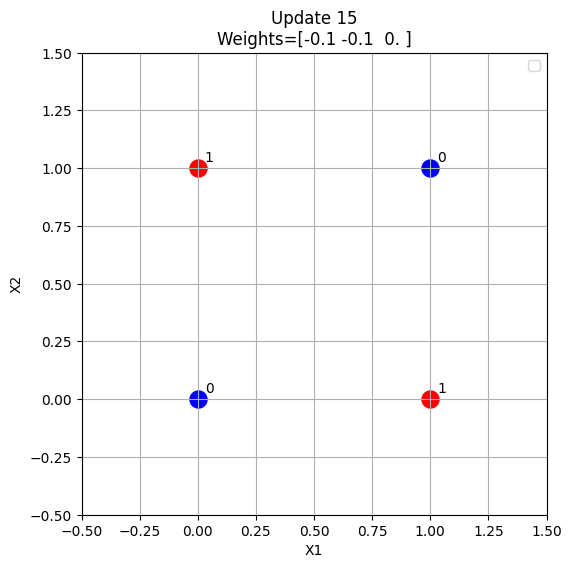

Update 16: [ 0.  -0.1  0.1]


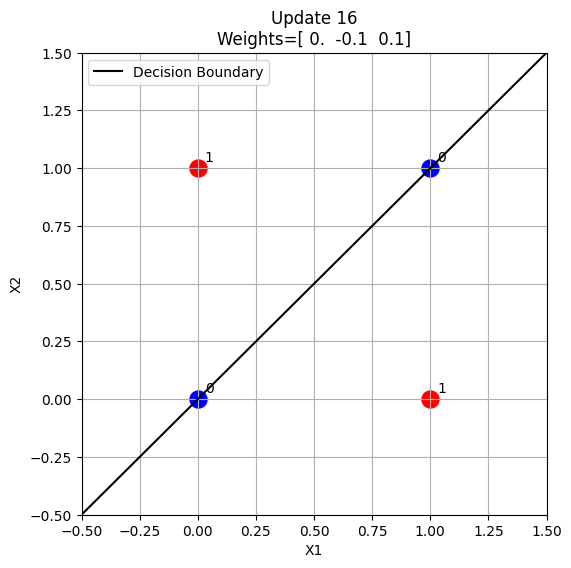

Update 17: [0.1 0.  0.1]


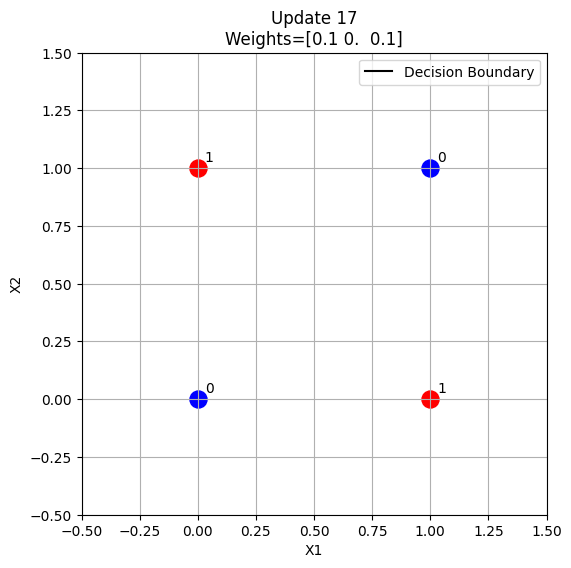

Update 18: [ 0.  -0.1  0. ]


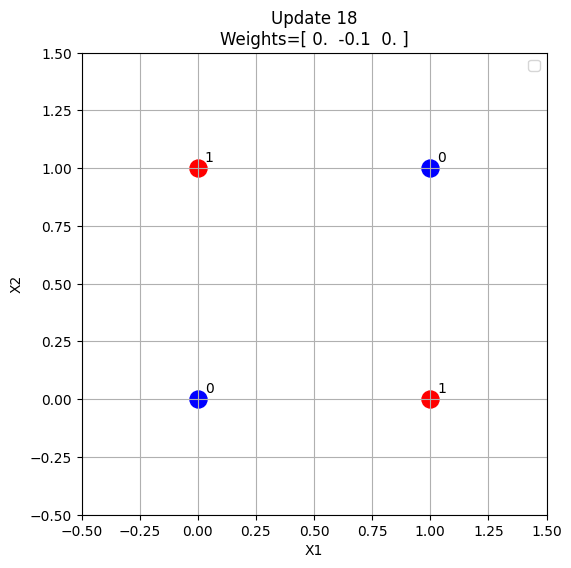


Epoch: 6
Update 19: [-0.1 -0.1  0. ]


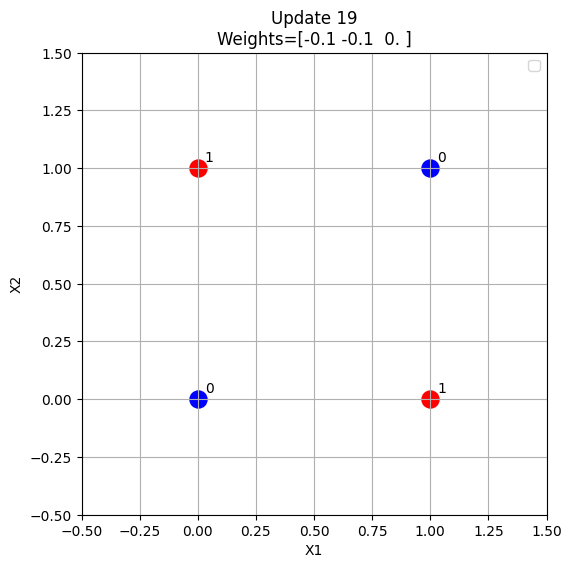

Update 20: [ 0.  -0.1  0.1]


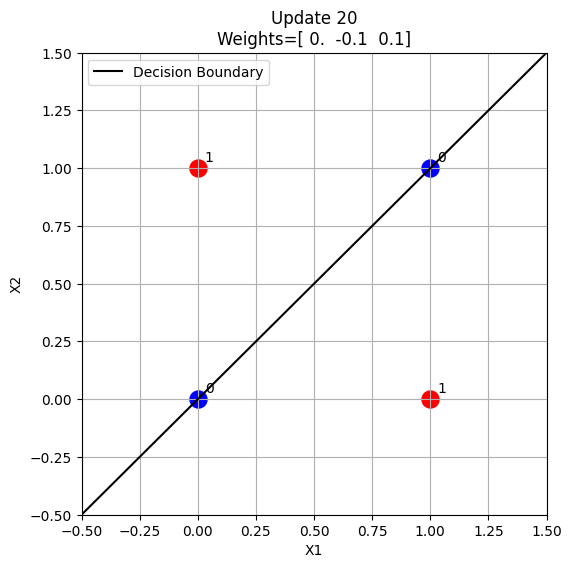

Update 21: [0.1 0.  0.1]


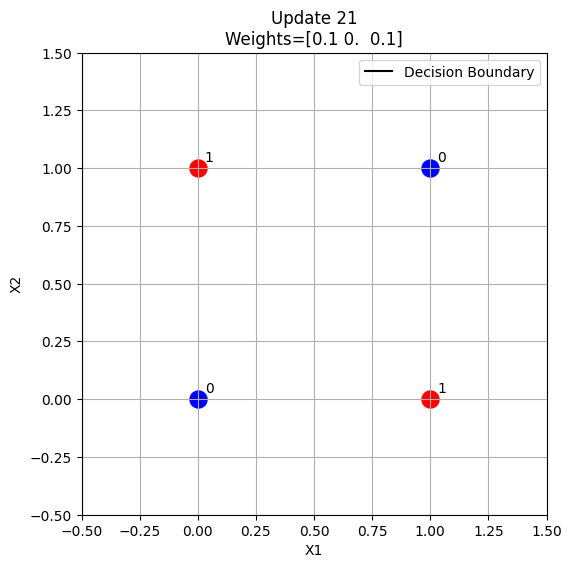

Update 22: [ 0.  -0.1  0. ]


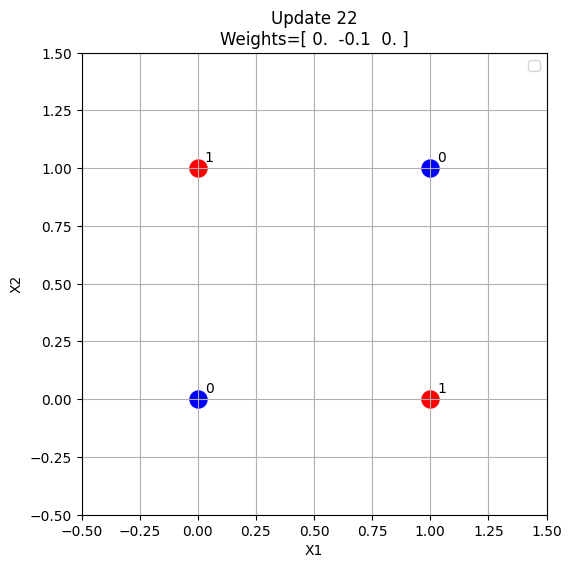


Epoch: 7
Update 23: [-0.1 -0.1  0. ]


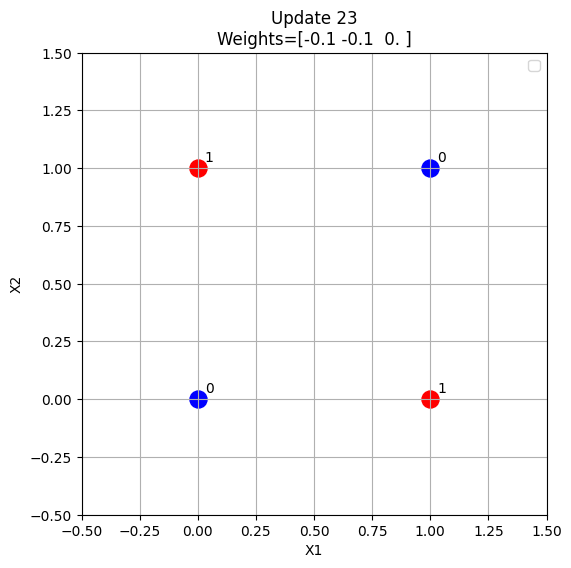

Update 24: [ 0.  -0.1  0.1]


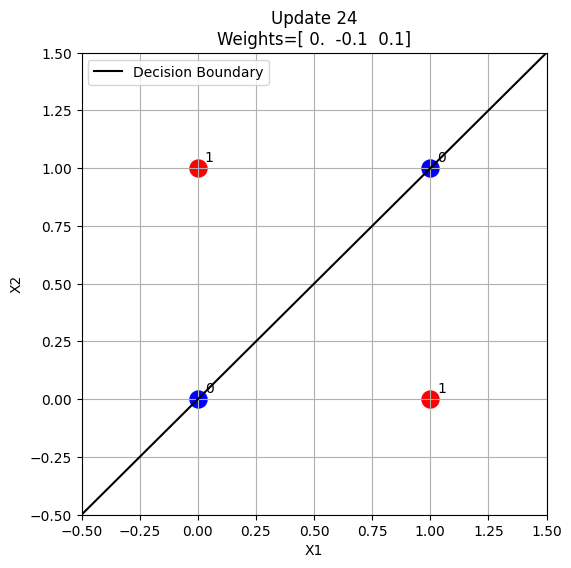

Update 25: [0.1 0.  0.1]


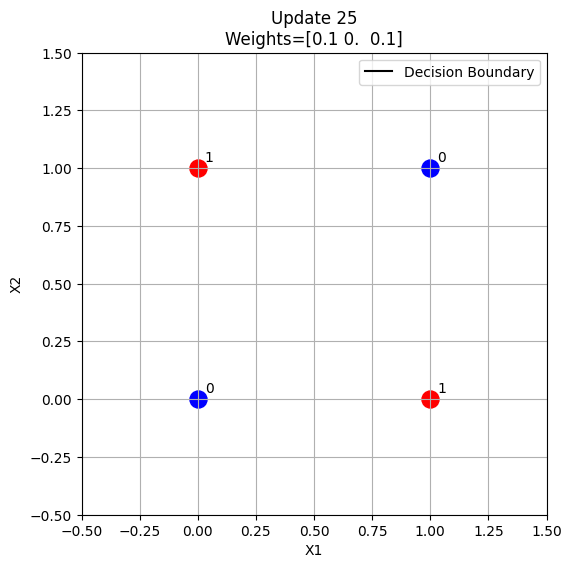

Update 26: [ 0.  -0.1  0. ]


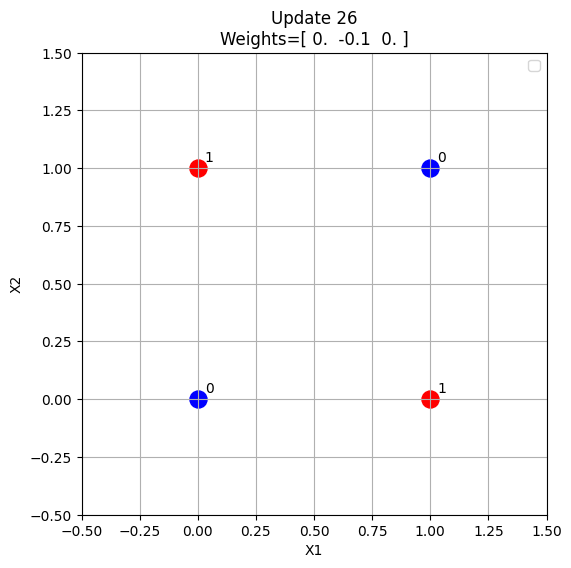


Epoch: 8
Update 27: [-0.1 -0.1  0. ]


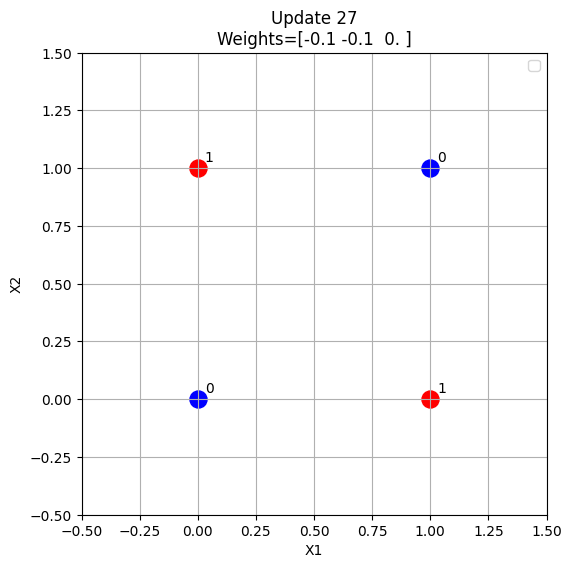

Update 28: [ 0.  -0.1  0.1]


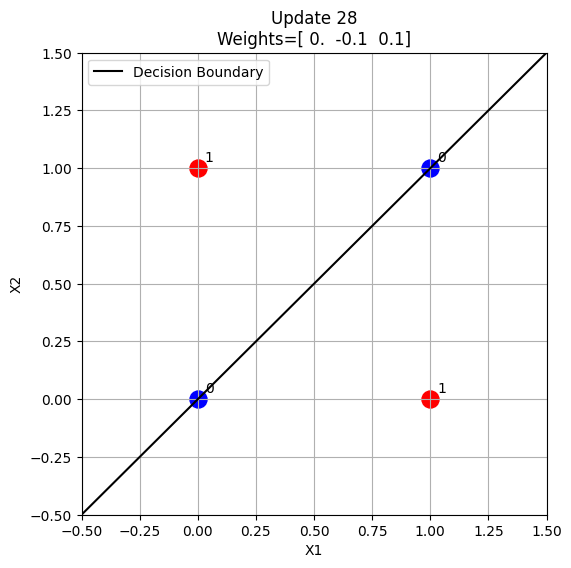

Update 29: [0.1 0.  0.1]


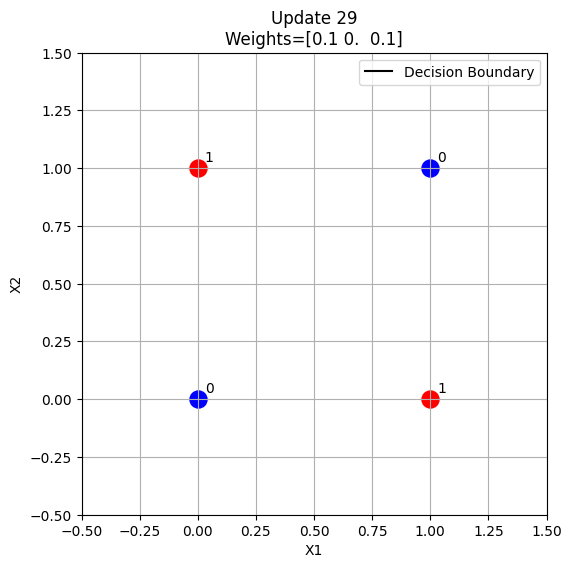

Update 30: [ 0.  -0.1  0. ]


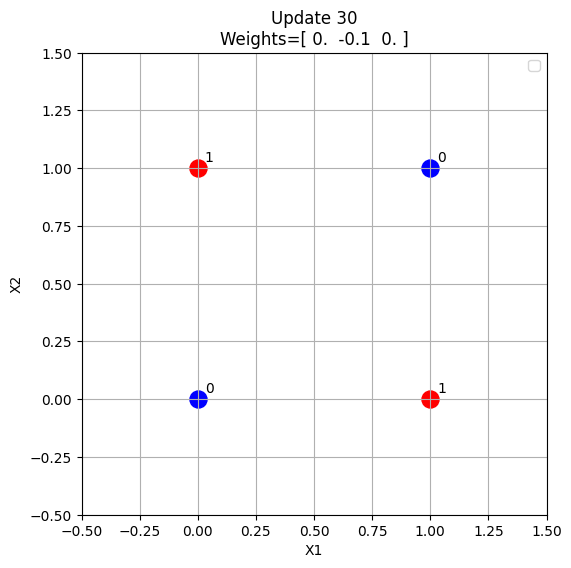


Epoch: 9
Update 31: [-0.1 -0.1  0. ]


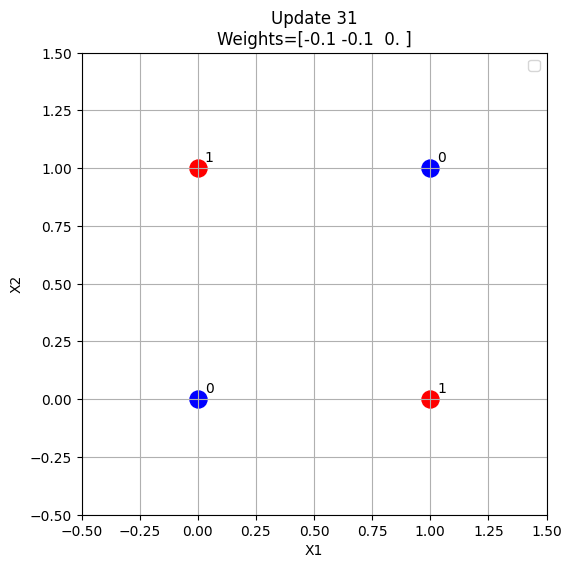

Update 32: [ 0.  -0.1  0.1]


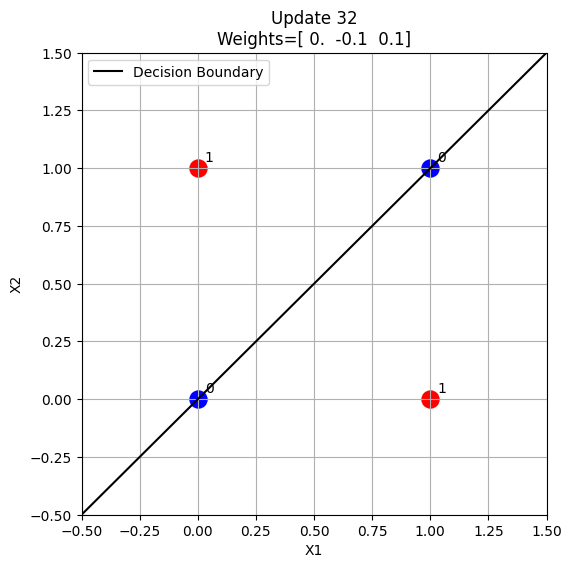

Update 33: [0.1 0.  0.1]


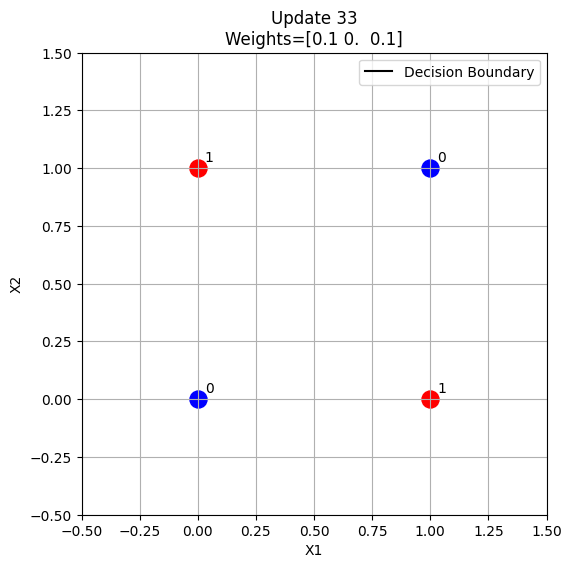

Update 34: [ 0.  -0.1  0. ]


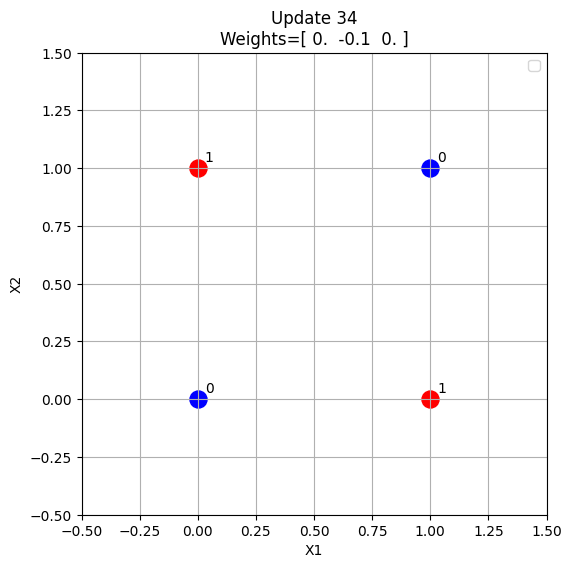


Epoch: 10
Update 35: [-0.1 -0.1  0. ]


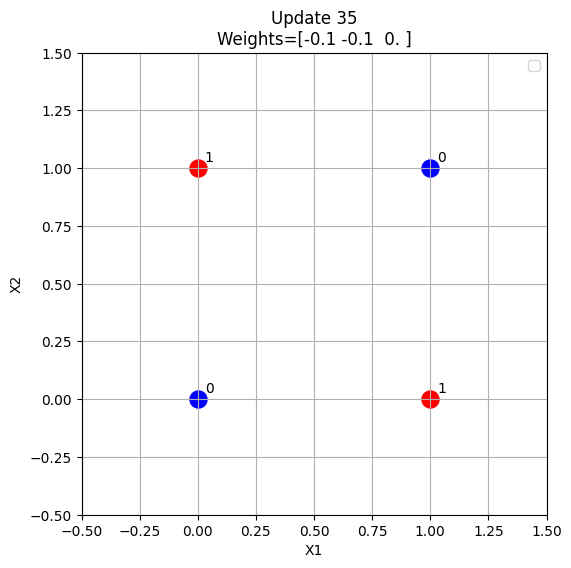

Update 36: [ 0.  -0.1  0.1]


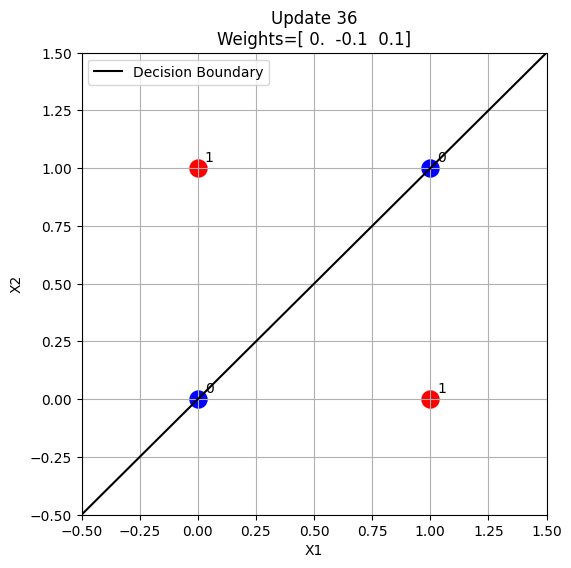

Update 37: [0.1 0.  0.1]


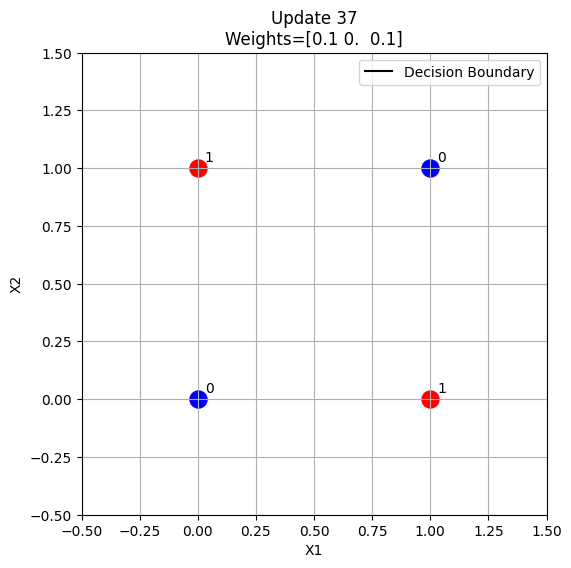

Update 38: [ 0.  -0.1  0. ]


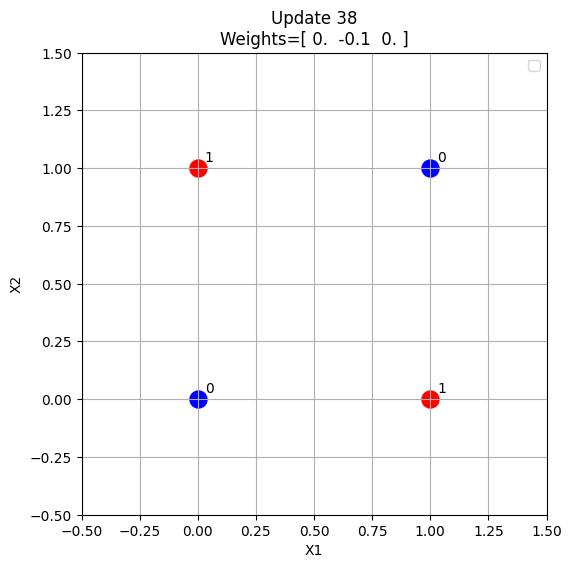

In [7]:
for epoch in range(epochs):

    print("\nEpoch:", epoch+1)

    errors = 0

    for i in range(len(X_bias)):

        prediction = activation(
            np.dot(weights, X_bias[i])
        )

        error = y[i] - prediction

        if error != 0:

            weights += (
                learning_rate *
                error *
                X_bias[i]
            )

            errors += 1
            update_count += 1

            print(
                f"Update {update_count}:",
                weights
            )

            plot_boundary(
                weights,
                update_count
            )

    if errors == 0:
        print("Converged")
        break


Final Weights:
[ 0.  -0.1  0. ]


/tmp/ipykernel_1098/1801390950.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


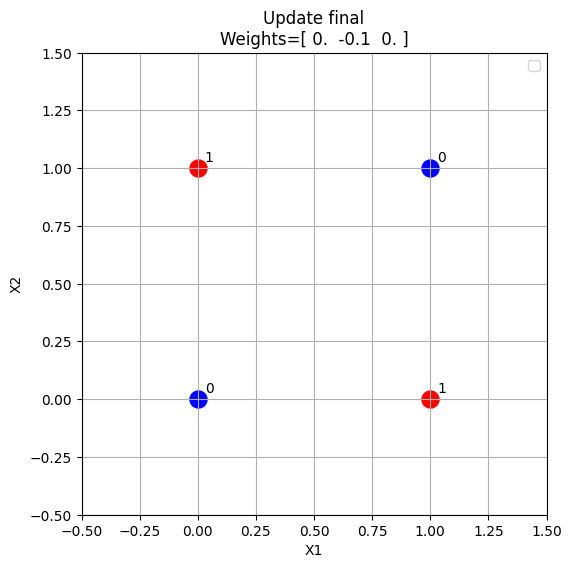

In [8]:
print("\nFinal Weights:")
print(weights)

plot_boundary(
    weights,
    "final"
)